# Objetivo

O objetivo desta análise é identificar padrões que diferenciam transações fraudulentas de transações legítimas. A linguagem de programação utilizada foi `Python`, e a bibloteca utilizada para a visualização de dados foi `Pandas`, responsável por fornecer estruturas de dados essenciais para a análise, como o `dataframe`. A biblioteca para manipulação de números foi `Numpy` e `StandardScaler` para padronização e separação para teste e treino do modelo.

# Passo 1: Coleta de dados

Utilizando o `read.csv` do **Pandas**, os dados do **dataset** que contém informações de transações realizadas por cartões de crédito são carregados e o resultado é armazenado no **dataframe** `df`.

In [ ]:
import pandas as pd

url ="https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

# Visualização das 5 primeiras linhas do dataset
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Para a maior compreesão dos dados, podemos utilizar o `df.columns`, que lista todas as colunas do **dataset**.

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Outra função que pode ser útil é a `df.info`, que informa a quantidade de colunas, tipo de dados, quantidade de valores nulos por coluna e o consumo de memória do **dataset**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

O **dataset** contém várias colunas numéricas que representam caracteristicas das transações bancárias, além de uma coluna que indica se a transação é ou não fraudulenta.

Cada registro é uma operação feita por cartão de crédito. A coluna `Time` representa o momento da transação. Não se trata de uma data comum, mas uma váriavel númerica que indica o tempo desde o início até a coleta de dados.

A coluna `V1` até a `V28` são variáveis transformadas. Os dados originais foram processados utilizando técnicas de PCA para preservar a privacidade.

A penúltima coluna se chama `Amount` e representa o valor da transação. Essa variável é importante, porque as fraudes podem ter padrões específicos de valor.

A coluna `Class`, a última coluna da visualização, indica se a transação é ou não fraudulenta, sendo 0 indicando uma transação legítima, e 1 indicando uma fraude.

Para verificar como as classes estão distribuidas em números inteiros, podemos usar o método `value_counts`, que contabiliza quantas vezes cada valor aparece na coluna.

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


Para calcular a proporção em porcentagem dos valores da coluna `Class`, podemos usar o `normalize=Tru`e.

In [ ]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


Como podemos ver, as transações legítimas representam 99,8% e apenas 0.17% são fraudes. Isso pode significar que o dataset está desbalanceado que é quando uma classe aparece mais que a outra. Isso pode fazer com que o modelo aprenda errado. Exemplo: O modelo pode responder sempre que não é fraude. Ele vai acertar a maioria das vezes, mas não conseguirá fazer o mais importante, que é detectar uma fraude.

# Passo 2: Modelagem de dados

## Feature Engineering

Agora, criaremos variaveis para ajudar o nosso modelo. A biblioteca numpy, ajuda a realizar operações matemáticas, entre outrras coisas, nos ajudará com essa etapa.

In [ ]:
import numpy as np
df['Amount_log'] = np.log1p(df['Amount'])

`df['Amout_log] = np.log1p(df['Amount']) `aplica uma transformação logarítimica nos valores da columa `Amount`. Isso evita problemas com valores igual a `0`, já que o log 0 não vai existir. Isso porque em dados financeiros, como valores de transações, é normal ter valores muito diferentes em si, e isso pode dificultar o aprendizado do modelo.

## Padronização dos dados

Aqui, usaremos a ferramenta sklearn, da biblioteca Standard Scaler. Ela transformará os dados para que tenham a média igual a `0` e desvio padrão igual a `1`, para que os valores fiquem na mesma escala, independente tamanho original. Dessa forma valores muito grandes ou muito pequenos passam a ser comparaveis. O resultado será armazedo em outra coluna chamada `Amount_scaled`.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

## Preparação dos dados para testes e treinamento do modelo

Separamos as variaveis em `x` e `y`. O `x` representa as variaveis de entrada e o` y` representa o alvo (`'Class'`). Assim, a coluna `Class` irá indicar se a transação é um fraude ou não.

O `train_test_split `separa os dados em conjuntos de **treino** e **teste**. O conjunto de treino é utilizado para ensinar o modelo, e o conjunto de teste avalia o modelo posteriormente.

O `test_size=0.3` representa 30% dos dados que vão para teste, e os outros 70% irão para treino. O `random_state=42 `garante que a divisão seja a mesma. O `stratify=y `garante que a proporção de fraudes e não fraudes seja mantida para ambos os conjuntos.

In [ ]:
from sklearn.model_selection import train_test_split

x = df.drop(['Class'], axis=1)
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
)

# Passo 3: Avaliação do modelo
## Regressão Logística

O **Logistic Regression** é um modelo de classificação, que é usado para prever categorias. No nosso caso queremos prever se a transação é fraude ou não. Esse modelo será usado como baseline, ou seja, servirá de referência para que outros modelos posteriores funcionem corretamente.

O parametro `max-iter `define o número de interações. O `model_fit` é usado para que o modelo aprenda padrões a partir dos dados de treino. Ele tenta encontrar relações entre as variaveis, features e o resultado, fraude ou não fraude. O` model_predict `é usado para fazer previsões com os dados de teste.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ao rodar o código, recebemos um warning, porque o modelo não conseguiu terminar o número de interações definidos. Vamos continuar mesmo assim.

Para ver como o modelo se saiu, podemos utilizar o classification_report, que permite que vejamos as métricas mais importantes da nossa avaliação.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



O `precision` ficou em **0.87**, o que significaria que o modelo classificou 87% como fraudes.

O `recall` ficou em **0.68**, o que significaria que o modelo classificou **68%** como fraudes reais. Isso significa que o modelo estaria deixando passar cerca de **32%** de fraudes reais.

O `f1-score` ficou em **0.77**. o que significaria que **77%**, que seria uma média harmonica entre **precisão** e **recall**, seriam classificadas como fraudes. Essa classe atua como uma visão geral do modelo.

A **accuracy** ficou em **1.00**, ou seja 100%. A acuracia tão alta muitas vezes é um mau sinal. Contexto do nosso problema, pode significar que, pelo fato do dataset ser desbalanceado, acuracia pode estar viciada, prevendo a classe zero.

No nosso contexto, a classe mais importante para a analise é a classe `recall`.

## ROC Curve

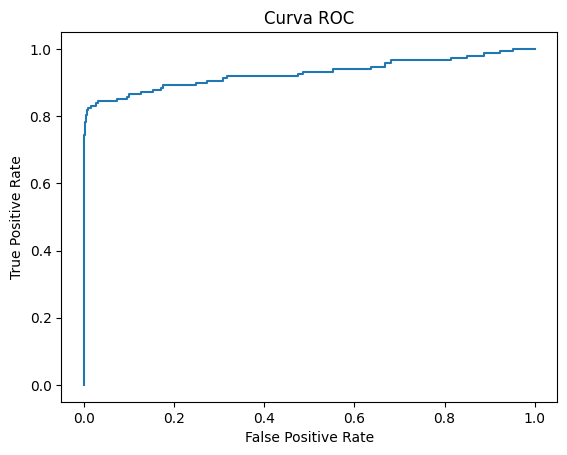

AUC: 0.9272042339543365


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title('Curva ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

print('AUC:', roc_auc_score(y_test, y_probs))

Também podemos utilizar a curva roc para está analise. Essa métrica é muito importante para modelos de classificação. Esse gráfico nos mostra o desempenho do modelo eem diferentes lineares de decisão.

No eixo horizontal temos o **False Positive Rate**, que representa a taxa de falsos positivos, ou seja quantas transações legítimas foram classificadas como fraude. No eixo vertical temos o **True Position Rate** que representa o mesmo que o **recall**, ou seja fraudes reais o modelo realmente conseguiu identificar. Cada ponto da curva vai representar um limite diferente da decisão do modelo. Ao invés de se fixar em um único limite, podemos analisar o comportamento geral. Quanto mais a curva se aproxima do canto esquerdo, melhor é o modelo. Isso porquê isso significa alto **recall** e baixo erro.

Se a curva fosse uma linha reta diagonal, o modelo seria aleatório, ou seja, não teria capacidade de distinguir fraude e não fraude.

A área sobre a curva foi de aproximadamente 93 (92.8). Um valor próximo de 1 indica que o modelo está muito bom. Um valor próximo de 0.5 indica dados aleatórios. Isso significa que nosso modelo tem boa capacidade de separar fraudes de transações legítimas.

## Precision-Recall Curve

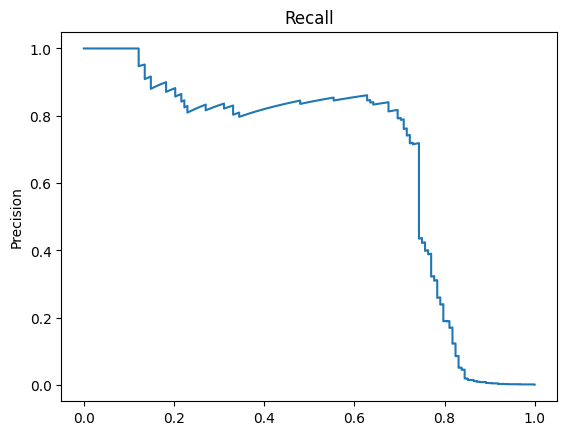

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.title('Recall')
plt.ylabel('Precision')
plt.show()

Essa metrica é ainda mais importante em problemas de fraudes desbalanceadas.

No eixo horizontal, temos o **recall**, ou seja, quantas fraudes o modelo consegue indentificar e no eixo vertical temos o **precision**, ou seja, entre as transações como fraude, quantas realmente são fraude.

Esse gráfico mostra o equilíbrio entre essas duas métricas. Quando tentamos aumentar o **recall**, o **precision** diminui e vice-versa.

Quando o **precision** está muito alto, ele só aponta fraudes quando tem muita certeza e o **recall** é baixo, o que significa que muitas fraudes passam despercebidas.

Quando o **recall** está muito alto, o modelo passa a identificar mais fraudes, porém o **precision** cai, e aumentam os falsos positivos.

## Balanceamento de dados


In [ ]:
## Undersampling

fraudes = df[df['Class'] == 1]
legitimas = df[df['Class'] == 0].sample(n=len(fraudes), random_state=42)

df_balanced = pd.concat([fraudes, legitimas])

Quando o objetivo é criar um dataset equilibrado, com a mesma quantidade de fraudes e não fraudes, podemos utilizar o `undersampling`.

Aqui, pegamos todas as fraudes e depois seleciona a mesma quantidade de transações usando o sample. Ou seja, reduzimos a classe majoritária (classe 0), para ficar do mesmo tamanho da classe minoritária (classe 1) e por fim, junta tudo.

O modelo aprende a indentificar fraudes, mas acaba perdendo muitos dados, então podem reduzir a qualidade dos dados.

In [ ]:
## Oversampling

from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_resampled, y_resampled = smote.fit_resample(x, y)

No oversampling, são criados novos exemplos sintéticos da classe minoritária. O ponto positivo dessa solução é são se perde dados e se aumenta a representação da classe fraude. Por outro lado, os dados criados são artificiais, então pode incluir ruído.

A única forma se saber qual seria a melhor forma de balancear os dados é testando.